<a href="https://colab.research.google.com/github/tsaltsaeca-droid/KAL/blob/main/SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan upload gambar pemandangan...


Saving gambar.jpg to gambar.jpg
Ukuran gambar: 465 x 600


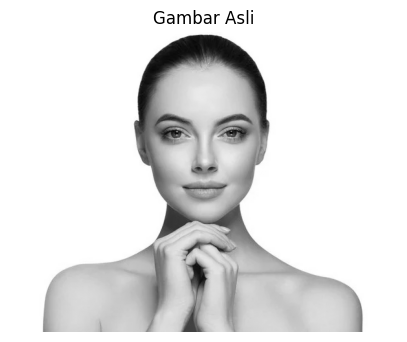

Memulai proses SVD...
Ukuran matriks hasil SVD
U  : (465, 465)
S  : (465,)
Vt : (465, 600)


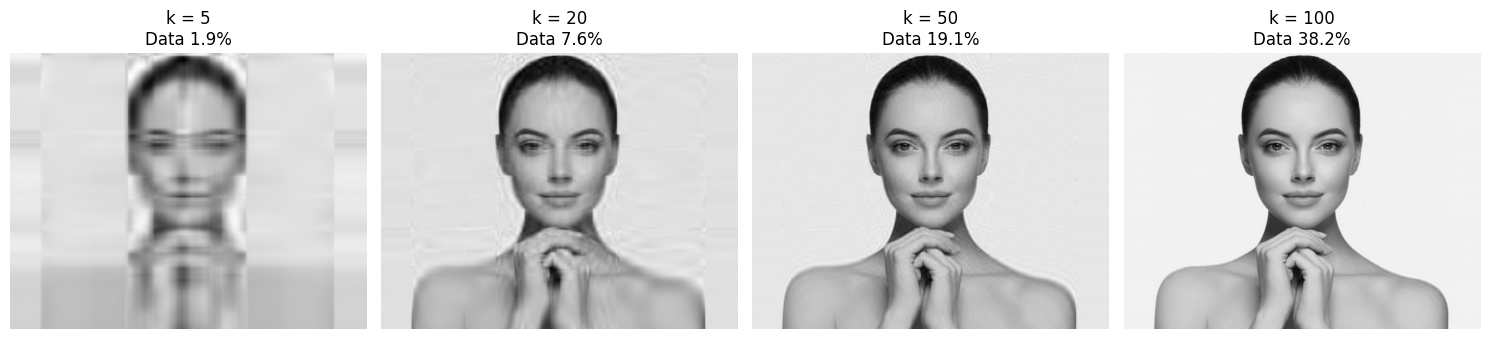

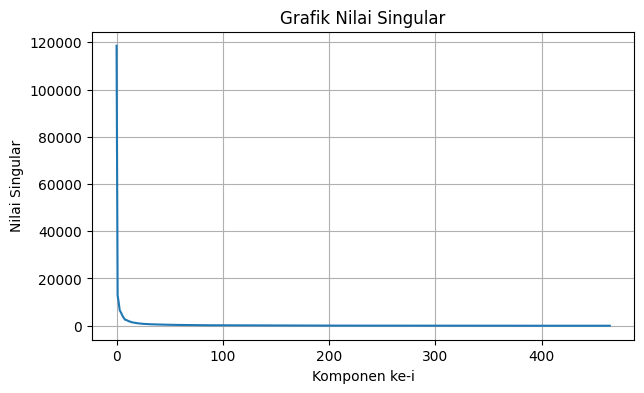

In [ ]:
# =========================================================
# SVD PADA GAMBAR PEMANDANGAN (GOOGLE COLAB)
# =========================================================

# =========================================================
# 1. IMPORT LIBRARY
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# =========================================================
# 2. UPLOAD GAMBAR
# =========================================================
print("Silakan upload gambar pemandangan...")

uploaded = files.upload()

# Mengambil nama file yang diupload
nama_file = list(uploaded.keys())[0]

# =========================================================
# 3. MEMBACA GAMBAR
# =========================================================
gambar = Image.open(nama_file)

# Ubah ke grayscale
gambar = gambar.convert("L")

# Ubah menjadi array numpy
A = np.array(gambar)

# Ukuran gambar
h, w = A.shape

print("Ukuran gambar:", h, "x", w)

# =========================================================
# 4. MENAMPILKAN GAMBAR ASLI
# =========================================================
plt.figure(figsize=(5,5))

plt.imshow(A, cmap='gray')

plt.title("Gambar Asli")

plt.axis('off')

plt.show()

# =========================================================
# 5. PROSES SVD
# =========================================================
print("Memulai proses SVD...")

# Rumus:
# A = U . S . Vt

U, S, Vt = np.linalg.svd(A, full_matrices=False)

print("Ukuran matriks hasil SVD")
print("U  :", U.shape)
print("S  :", S.shape)
print("Vt :", Vt.shape)

# =========================================================
# 6. REKONSTRUKSI GAMBAR
# =========================================================

# Nilai k
nilai_k = [5, 20, 50, 100]

fig, axes = plt.subplots(1, len(nilai_k), figsize=(15,5))

for i, k in enumerate(nilai_k):

    # Potong matriks
    U_k = U[:, :k]

    S_k = np.diag(S[:k])

    Vt_k = Vt[:k, :]

    # Rekonstruksi
    hasil = U_k @ S_k @ Vt_k

    # Hitung rasio data
    total_asli = h * w

    total_svd = (h * k) + k + (k * w)

    rasio = (total_svd / total_asli) * 100

    # Tampilkan hasil
    axes[i].imshow(hasil, cmap='gray')

    axes[i].set_title(f"k = {k}\nData {rasio:.1f}%")

    axes[i].axis('off')

plt.tight_layout()

plt.show()

# =========================================================
# 7. GRAFIK NILAI SINGULAR
# =========================================================
plt.figure(figsize=(7,4))

plt.plot(S)

plt.title("Grafik Nilai Singular")

plt.xlabel("Komponen ke-i")

plt.ylabel("Nilai Singular")

plt.grid(True)

plt.show()

Silakan upload gambar...


Saving gambar.jpg to gambar (2).jpg

Ukuran gambar asli : 465 x 600


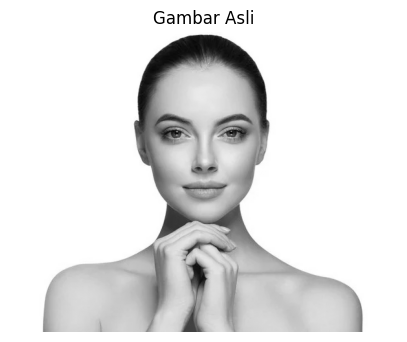


Memulai proses SVD...

UKURAN MATRIKS SVD
A      = (465, 600)
U      = (465, 465)
Sigma  = (465, 600)
Vt     = (600, 600)

POTONGAN MATRIKS

Potongan Matriks A (5x5)
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

Potongan Matriks U (5x5)
[[0.05 0.02 0.08 0.01 0.08]
 [0.05 0.02 0.08 0.01 0.08]
 [0.05 0.02 0.08 0.01 0.08]
 [0.05 0.02 0.08 0.01 0.08]
 [0.05 0.02 0.08 0.01 0.08]]

Potongan Matriks Sigma (5x5)
[[464.84   0.     0.     0.     0.  ]
 [  0.    50.41   0.     0.     0.  ]
 [  0.     0.    38.74   0.     0.  ]
 [  0.     0.     0.    25.43   0.  ]
 [  0.     0.     0.     0.    22.4 ]]

Potongan Matriks Vt (5x5)
[[ 0.05  0.05  0.05  0.05  0.05]
 [-0.   -0.   -0.   -0.   -0.  ]
 [ 0.    0.    0.    0.    0.  ]
 [-0.01 -0.01 -0.01 -0.01 -0.01]
 [-0.01 -0.01 -0.01 -0.01 -0.01]]

10 Nilai Singular Pertama
[464.84  50.41  38.74  25.43  22.4   18.72  14.96  12.47   9.96   9.65]

PEMBUKTIAN A = U × Σ × Vᵀ

Potongan A Asli (5x5)
[[1. 1. 1. 1

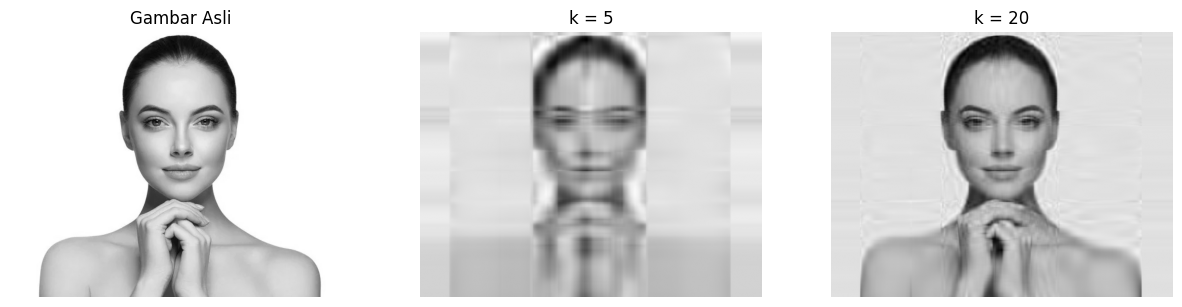


ANALISIS NILAI k

10 Singular Value Pertama
[464.84  50.41  38.74  25.43  22.4   18.72  14.96  12.47   9.96   9.65]

10 Energi Pertama (σ²)
[216075.25   2540.82   1501.15    646.66    501.77    350.35    223.91
    155.43     99.14     93.2 ]

Energi Total = 222846.297

PEMBUKTIAN k = 5
Energi 5 komponen pertama
[216075.25   2540.82   1501.15    646.66    501.77]

Jumlah Energi = 221265.6556
Persentase Energi = 99.29 %

PEMBUKTIAN k = 20
Jumlah Energi = 222577.0667
Persentase Energi = 99.88 %

PENENTUAN k OTOMATIS
Pada komponen ke-1, energi kumulatif mencapai 96.96%
Sehingga k = 1 dipilih untuk mempertahankan minimal 95% informasi gambar.


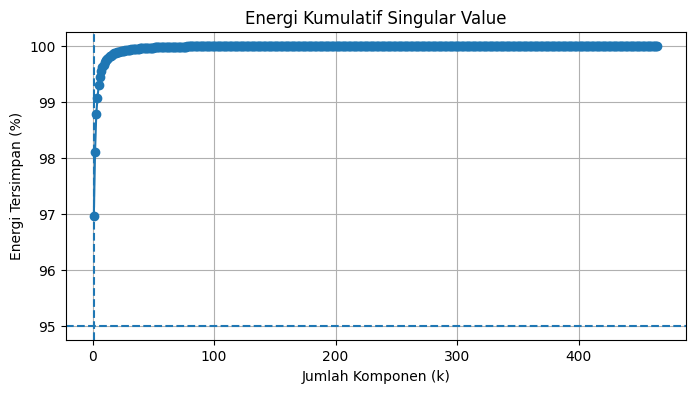


PERHITUNGAN KOMPRESI (k = 20)
Total data asli = 279000
Total data setelah SVD = 21320
Persentase data tersimpan = 7.64%
Penghematan data = 92.36%


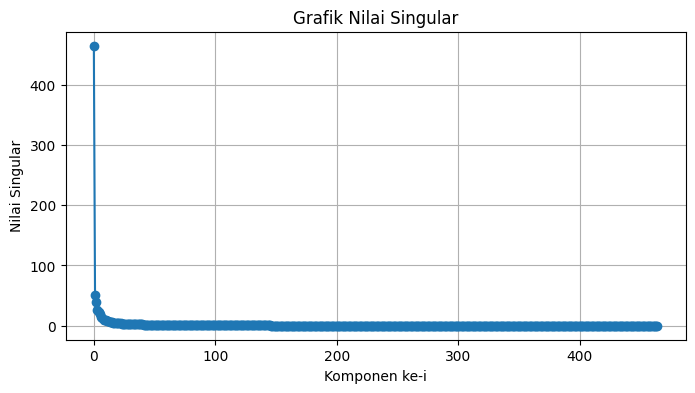

In [6]:
# =========================================================
# SVD PADA GAMBAR + PEMBUKTIAN UΣVᵀ + ANALISIS NILAI k
# =========================================================

# =========================================================
# 1. IMPORT LIBRARY
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# =========================================================
# 2. AGAR ANGKA LEBIH RAPI
# =========================================================
np.set_printoptions(
    precision=2,
    suppress=True
)

# =========================================================
# 3. UPLOAD GAMBAR
# =========================================================
print("Silakan upload gambar...")

uploaded = files.upload()

nama_file = list(uploaded.keys())[0]

# =========================================================
# 4. MEMBACA GAMBAR
# =========================================================
gambar = Image.open(nama_file)

# Ubah ke grayscale
gambar = gambar.convert("L")

# Mengikuti ukuran gambar asli
A = np.array(gambar, dtype=float)

# Normalisasi
A = A / 255.0

m, n = A.shape

print("\nUkuran gambar asli :", m, "x", n)

# =========================================================
# 5. TAMPILKAN GAMBAR ASLI
# =========================================================
plt.figure(figsize=(5,5))

plt.imshow(A, cmap='gray')

plt.title("Gambar Asli")

plt.axis('off')

plt.show()

# =========================================================
# 6. PROSES SVD LENGKAP
# =========================================================
print("\nMemulai proses SVD...")

U, S, Vt = np.linalg.svd(A, full_matrices=True)

# =========================================================
# 7. MEMBENTUK MATRIKS SIGMA (m x n)
# =========================================================
Sigma = np.zeros((m, n))

np.fill_diagonal(Sigma, S)

# =========================================================
# 8. MENAMPILKAN UKURAN MATRIKS
# =========================================================
print("\n=================================================")
print("UKURAN MATRIKS SVD")
print("=================================================")

print("A      =", A.shape)
print("U      =", U.shape)
print("Sigma  =", Sigma.shape)
print("Vt     =", Vt.shape)

# =========================================================
# 9. MENAMPILKAN POTONGAN MATRIKS
# =========================================================
print("\n=================================================")
print("POTONGAN MATRIKS")
print("=================================================")

print("\nPotongan Matriks A (5x5)")
print(np.round(A[:5,:5], 2))

print("\nPotongan Matriks U (5x5)")
print(np.round(U[:5,:5], 2))

print("\nPotongan Matriks Sigma (5x5)")
print(np.round(Sigma[:5,:5], 2))

print("\nPotongan Matriks Vt (5x5)")
print(np.round(Vt[:5,:5], 2))

print("\n10 Nilai Singular Pertama")
print(np.round(S[:10], 4))

# =========================================================
# 10. PEMBUKTIAN A = UΣVᵀ
# =========================================================
print("\n=================================================")
print("PEMBUKTIAN A = U × Σ × Vᵀ")
print("=================================================")

A_bukti = U @ Sigma @ Vt

print("\nPotongan A Asli (5x5)")
print(np.round(A[:5,:5], 4))

print("\nPotongan A Hasil UΣVᵀ (5x5)")
print(np.round(A_bukti[:5,:5], 4))

error = np.max(np.abs(A - A_bukti))

print("\nError Maksimum =", error)

if error < 1e-10:
    print("Kesimpulan : A = UΣVᵀ terbukti.")
else:
    print("Kesimpulan : terdapat selisih numerik.")

# =========================================================
# 11. REKONSTRUKSI k = 5
# =========================================================
k1 = 5

U5 = U[:, :k1]

S5 = np.diag(S[:k1])

Vt5 = Vt[:k1, :]

hasil5 = U5 @ S5 @ Vt5

# =========================================================
# 12. REKONSTRUKSI k = 20
# =========================================================
k2 = 20

U20 = U[:, :k2]

S20 = np.diag(S[:k2])

Vt20 = Vt[:k2, :]

hasil20 = U20 @ S20 @ Vt20

# =========================================================
# 13. MENAMPILKAN HASIL REKONSTRUKSI
# =========================================================
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(A, cmap='gray')
ax[0].set_title("Gambar Asli")
ax[0].axis('off')

ax[1].imshow(hasil5, cmap='gray')
ax[1].set_title("k = 5")
ax[1].axis('off')

ax[2].imshow(hasil20, cmap='gray')
ax[2].set_title("k = 20")
ax[2].axis('off')

plt.show()

# =========================================================
# 14. ANALISIS NILAI k
# =========================================================
print("\n=================================================")
print("ANALISIS NILAI k")
print("=================================================")

energi = S**2

energi_total = np.sum(energi)

print("\n10 Singular Value Pertama")
print(np.round(S[:10],4))

print("\n10 Energi Pertama (σ²)")
print(np.round(energi[:10],4))

print("\nEnergi Total =", round(energi_total,4))

# ---------------------------------------------------------
# k = 5
# ---------------------------------------------------------
energi5 = np.sum(energi[:5])

persen5 = energi5 / energi_total * 100

print("\n=================================================")
print("PEMBUKTIAN k = 5")
print("=================================================")

print("Energi 5 komponen pertama")
print(np.round(energi[:5],4))

print("\nJumlah Energi =", round(energi5,4))

print("Persentase Energi =", round(persen5,2), "%")

# ---------------------------------------------------------
# k = 20
# ---------------------------------------------------------
energi20 = np.sum(energi[:20])

persen20 = energi20 / energi_total * 100

print("\n=================================================")
print("PEMBUKTIAN k = 20")
print("=================================================")

print("Jumlah Energi =", round(energi20,4))

print("Persentase Energi =", round(persen20,2), "%")

# =========================================================
# 15. MENENTUKAN k OTOMATIS (95%)
# =========================================================
kumulatif = np.cumsum(energi)

persentase_kumulatif = kumulatif / energi_total

k95 = np.argmax(
    persentase_kumulatif >= 0.95
) + 1

print("\n=================================================")
print("PENENTUAN k OTOMATIS")
print("=================================================")

print(
    f"Pada komponen ke-{k95}, energi kumulatif mencapai "
    f"{persentase_kumulatif[k95-1]*100:.2f}%"
)

print(
    f"Sehingga k = {k95} dipilih untuk mempertahankan "
    f"minimal 95% informasi gambar."
)

# =========================================================
# 16. GRAFIK ENERGI KUMULATIF
# =========================================================
plt.figure(figsize=(8,4))

plt.plot(
    np.arange(1, len(S)+1),
    persentase_kumulatif * 100,
    marker='o'
)

plt.axhline(
    y=95,
    linestyle='--'
)

plt.axvline(
    x=k95,
    linestyle='--'
)

plt.title("Energi Kumulatif Singular Value")

plt.xlabel("Jumlah Komponen (k)")

plt.ylabel("Energi Tersimpan (%)")

plt.grid(True)

plt.show()

# =========================================================
# 17. KOMPRESI UNTUK k = 20
# =========================================================
total_asli = m * n

total_svd = (m * k2) + k2 + (k2 * n)

rasio = (total_svd / total_asli) * 100

print("\n=================================================")
print("PERHITUNGAN KOMPRESI (k = 20)")
print("=================================================")

print("Total data asli =", total_asli)

print("Total data setelah SVD =", total_svd)

print(f"Persentase data tersimpan = {rasio:.2f}%")

print(f"Penghematan data = {100-rasio:.2f}%")

# =========================================================
# 18. GRAFIK NILAI SINGULAR
# =========================================================
plt.figure(figsize=(8,4))

plt.plot(S, marker='o')

plt.title("Grafik Nilai Singular")

plt.xlabel("Komponen ke-i")

plt.ylabel("Nilai Singular")

plt.grid(True)

plt.show()